# Selamat Datang di Colab!

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

In [3]:
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/flower_recognition/archive.zip'
EXTRACT_PATH = '/content/flowers_data'
DATA_DIR = os.path.join(EXTRACT_PATH, 'flowers')

if os.path.exists(ZIP_PATH):
    print(f"File ZIP ditemukan. Memulai ekstraksi...")
    !mkdir -p {EXTRACT_PATH}
    !unzip -q {ZIP_PATH} -d {EXTRACT_PATH}
    print(f"Ekstraksi selesai. Dataset siap di: {DATA_DIR}")
else:
    print(f"ERROR: File ZIP tidak ditemukan di {ZIP_PATH}. Harap cek kembali lokasi.")

if os.path.exists(DATA_DIR):
    print("\nFolder Kelas Bunga yang terdeteksi:")
    print(os.listdir(DATA_DIR))

Mounted at /content/drive
File ZIP ditemukan. Memulai ekstraksi...
Ekstraksi selesai. Dataset siap di: /content/flowers_data/flowers

Folder Kelas Bunga yang terdeteksi:
['tulip', 'sunflower', 'daisy', 'dandelion', 'rose']


In [4]:
img_width, img_height = 150, 150
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42
)

validation_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"\nJumlah Kelas: {num_classes}, Nama Kelas: {class_names}")

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Jumlah Kelas: 5, Nama Kelas: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [5]:
input_shape = (img_width, img_height, 3)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

epochs = 5
print(f"\nMemulai pelatihan selama {epochs} epoch...")

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

print("\nPelatihan model selesai! 🟢")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,997 (18.42 MB)

 Trainable params: 4,828,997 (18.42 MB)

...


Memulai pelatihan selama 5 epoch...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.2429 - loss: 2.3592 - val_accuracy: 0.4327 - val_loss: 1.3115
Epoch 2/5
  1/108 ━━━━━━━━━━━━━━━━━━━━ 2:53 2s/step - accuracy: 0.5000 - loss: 1.3646

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.5000 - loss: 1.3646 - val_accuracy: 0.4627 - val_loss: 1.2764
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.4686 - loss: 1.2521 - val_accuracy: 0.5565 - val_loss: 1.2391
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.5312 - loss: 1.2419 - val_accuracy: 0.5481 - val_loss: 1.2329
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.4990 - loss: 1.1718 - val_accuracy: 0.5541 - val_loss: 1.1248

Pelatihan model selesai! 🟢


Found 860 images belonging to 5 classes.
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 487ms/step


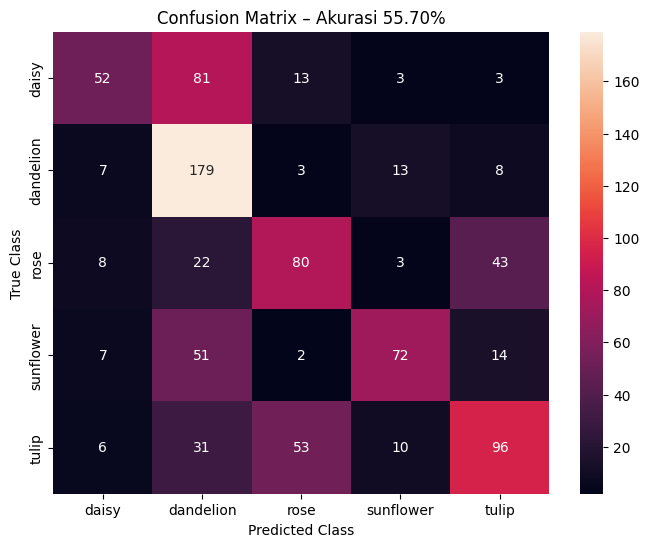

              precision    recall  f1-score   support

       daisy       0.65      0.34      0.45       152
   dandelion       0.49      0.85      0.62       210
        rose       0.53      0.51      0.52       156
   sunflower       0.71      0.49      0.58       146
       tulip       0.59      0.49      0.53       196

    accuracy                           0.56       860
   macro avg       0.59      0.54      0.54       860
weighted avg       0.59      0.56      0.55       860



In [6]:
val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(val_generator.classes, y_pred)

total_correct = np.trace(cm)
total_samples = np.sum(cm)
acc = total_correct / total_samples

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())

plt.title(f"Confusion Matrix – Akurasi {acc * 100:.2f}%")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

# Classification Report
print(classification_report(val_generator.classes, y_pred,
                            target_names=val_generator.class_indices.keys()))

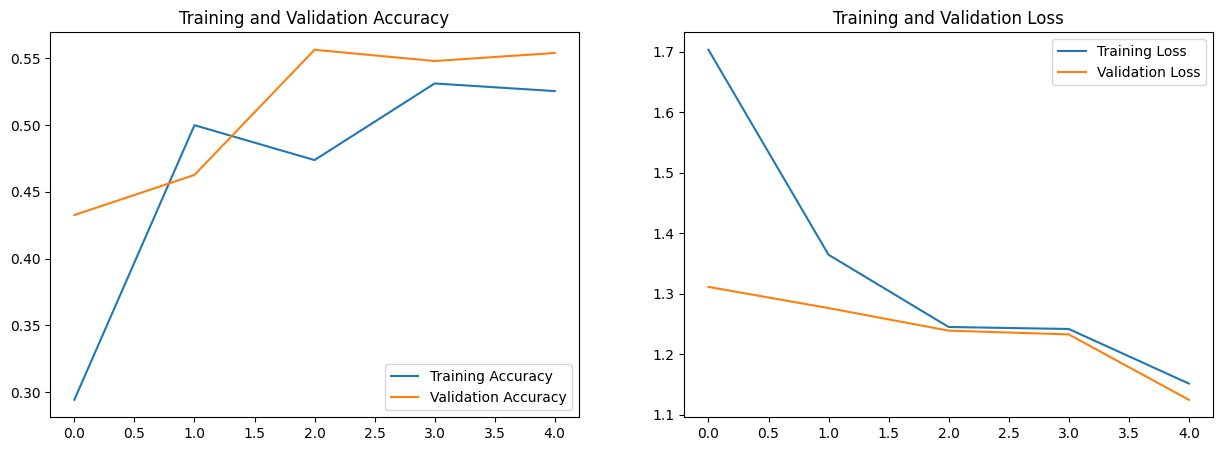

In [7]:
# Ambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [8]:
save_path = '/content/drive/MyDrive/flower_recognition/saved_models/flower_cnn_model.h5'

try:
    model.save(save_path)
    print(f"Model berhasil disimpan ke: {save_path}")
except Exception as e:
    print(f"ERROR saat menyimpan model: {e}")
    print("Pastikan Google Drive sudah di-mount dan path folder sudah benar.")

Model berhasil disimpan ke: /content/drive/MyDrive/flower_recognition/saved_models/flower_cnn_model.h5



Melakukan prediksi pada gambar: /content/flowers_data/flowers/daisy/14272874304_47c0a46f5a.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


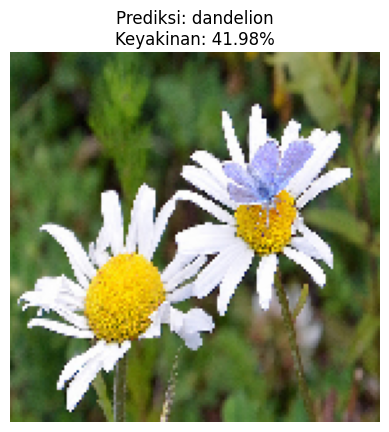

In [9]:
# Fungsi untuk Melakukan Prediksi
def predict_new_image(img_path):
    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)

    # Menambahkan dimensi batch dan normalisasi
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    predictions = model.predict(img_array)

    # Mendapatkan kelas dan probabilitas
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    # Visualisasi Hasil
    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class_name}\nKeyakinan: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

test_img_path = '/content/flowers_data/flowers/daisy/14272874304_47c0a46f5a.jpg'

print(f"\nMelakukan prediksi pada gambar: {test_img_path}")
predict_new_image(test_img_path)